In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Documents\C-DAC Internship\dcgm.csv")

In [3]:
df.head(3)

,Node,avgmemoryutilization_pct,avgsmutilization_pct,energyconsumed_joules,gpu_id,maxgpumemoryused_bytes,memoryutilization_pct_avg,memoryutilization_pct_max,memoryutilization_pct_min,pcierxbandwidth_megabytes_avg,...,pcietxbandwidth_megabytes_max,pcietxbandwidth_megabytes_min,powerusage_watts_avg,powerusage_watts_max,powerusage_watts_min,smutilization_pct_avg,smutilization_pct_max,smutilization_pct_min,totalexecutiontime_sec,id_job
0,r9170217-n750018,0.0,1.0,157521.0,0,2.645557e+09,3.0,24.0,0.0,1646.0,...,1530.0,676.0,44.0546,156.962,25.468,11.0,64.0,0.0,4452.47,4393785332
1,r44132-n469339,0.0,0.0,0.0,1,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.000,0.000,0.0,0.0,0.0,0.54,18177101425
2,r5354770-n172107,0.0,3.0,94816.0,0,2.917171e+07,0.0,0.0,0.0,1846.0,...,1872.0,1346.0,26.3725,27.483,25.979,6.0,43.0,0.0,8398.30,39529488078


In [8]:
df.isnull().sum()

avgmemoryutilization_pct         0
avgsmutilization_pct             0
energyconsumed_joules            0
gpu_id                           0
maxgpumemoryused_bytes           0
memoryutilization_pct_avg        0
memoryutilization_pct_max        0
memoryutilization_pct_min        0
pcierxbandwidth_megabytes_avg    0
pcierxbandwidth_megabytes_max    0
pcierxbandwidth_megabytes_min    0
pcietxbandwidth_megabytes_avg    0
pcietxbandwidth_megabytes_max    0
pcietxbandwidth_megabytes_min    0
powerusage_watts_avg             0
powerusage_watts_max             0
powerusage_watts_min             0
smutilization_pct_avg            0
smutilization_pct_max            0
smutilization_pct_min            0
totalexecutiontime_sec           0
power_time_product               0
memory_per_sec                   0
dtype: int64

In [ ]:
#Data preprocessing
df = df.drop(columns=["Node", "id_job"]) #Drop non numeric columns
df = df[(df["totalexecutiontime_sec"] > 0) & (df["maxgpumemoryused_bytes"] > 0)]
df = df.dropna()

In [ ]:
#Normalize power and memory columns to improve accuracy
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_normalize = ["powerusage_watts_avg", "maxgpumemoryused_bytes"]
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

In [6]:
# Derived feature: energy consumption proxy
df["power_time_product"] = df["powerusage_watts_avg"] * df["totalexecutiontime_sec"]

In [7]:
# Derived feature: memory demand over time (with safety against division by zero)
df["memory_per_sec"] = df["maxgpumemoryused_bytes"] / df["totalexecutiontime_sec"].replace(0, np.nan)

In [9]:
# Optional: Drop rows with NaN (in case of divide-by-zero)
df.dropna(inplace=True)
X = df.drop(columns=["totalexecutiontime_sec", "maxgpumemoryused_bytes"]).values
y_time = df["totalexecutiontime_sec"].values
df = df.replace([np.inf, -np.inf], np.nan).dropna()
X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(X, y_time, test_size=0.2, random_state=42)

Predicting CPUTimeRAW
R2 Score: 0.9859364558662101
RMSE: 13697.46984789707


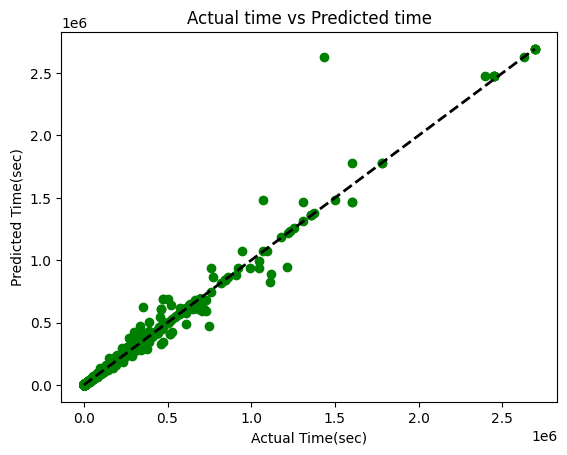

In [10]:
#PART 1:- predicting CPUTimeRAW
time_model = DecisionTreeRegressor(random_state=42)
time_model.fit(X_train_time, y_train_time)
y_pred_time = time_model.predict(X_test_time)
print("Predicting CPUTimeRAW")
print("R2 Score:", r2_score(y_test_time, y_pred_time))
print("RMSE:", np.sqrt(mean_squared_error(y_test_time, y_pred_time)))
plt.scatter(y_test_time, y_pred_time, color='green')
plt.plot([y_test_time.min(), y_test_time.max()], [y_test_time.min(), y_test_time.max()], 'k--', lw=2)
plt.xlabel('Actual Time(sec)')
plt.ylabel('Predicted Time(sec)')
plt.title('Actual time vs Predicted time')
plt.show()

In [11]:
#Predictind MaxRSS i.e amount of physical memory required by the job
X_mem = df.drop(columns=["totalexecutiontime_sec", "maxgpumemoryused_bytes"]).values
y_mem = df["maxgpumemoryused_bytes"].values
X_train_mem, X_test_mem, y_train_mem, y_test_mem = train_test_split(X, y_mem, test_size=0.2, random_state=42)
mem_model = DecisionTreeRegressor(random_state=42)
mem_model.fit(X_train_mem, y_train_mem)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [12]:
#memory prediction
y_pred_mem = mem_model.predict(X_test_mem)
print("Predicting MaxRSS:")
print("R2 score:", r2_score(y_test_mem, y_pred_mem))
print("Root Mean Square Error", mean_squared_error(y_test_mem, y_pred_mem))

Predicting MaxRSS:
R2 score: 0.9313203541095112
Root Mean Square Error 0.0073641386083310905


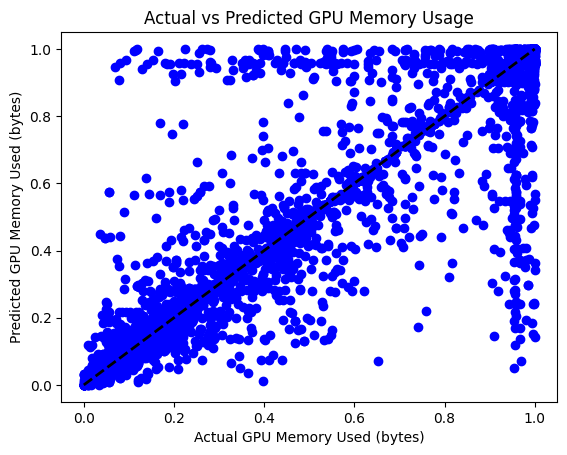

In [13]:
plt.scatter(y_test_mem, y_pred_mem, color='blue')
plt.plot([y_test_mem.min(), y_test_mem.max()], [y_test_mem.min(), y_test_mem.max()], 'k--', lw=2)
plt.xlabel('Actual GPU Memory Used (bytes)')
plt.ylabel('Predicted GPU Memory Used (bytes)')
plt.title('Actual vs Predicted GPU Memory Usage')
plt.show()